# **Kenshi: ARIMA + Delta-LSTM Dynamic Hybrid**

(Given the copies of plots in the markdown, if it's not visible in git or editors)

## **Imports**

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings("ignore")

import plotly.graph_objects as go
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

import torch
import torch.nn as nn

## **Loading the data**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/oil_prices_2426.csv')
df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df = df.sort_values("date").set_index("date")

y = df["price (dollars)"].astype(float).asfreq("D")

print("Loaded")
print("Start:", y.index.min(), "| End:", y.index.max(), "| n:", len(y))

Loaded
Start: 2024-09-21 00:00:00 | End: 2026-02-02 00:00:00 | n: 500


## **Train/Val/Test split**

In [ ]:
TEST_DAYS = 90
VAL_DAYS = 60

y_train_full = y.iloc[:-TEST_DAYS]
y_test = y.iloc[-TEST_DAYS:]

y_train_core = y_train_full.iloc[:-VAL_DAYS]
y_val = y_train_full.iloc[-VAL_DAYS:]

print("Train core:", len(y_train_core))
print("Validation:", len(y_val))
print("Test:", len(y_test))

fig = go.Figure()
fig.add_trace(go.Scatter(x=y_train_core.index, y=y_train_core.values, name="Train core", line=dict(width=2)))
fig.add_trace(go.Scatter(x=y_val.index, y=y_val.values, name="Validation", line=dict(width=2)))
fig.add_trace(go.Scatter(x=y_test.index, y=y_test.values, name="Test", line=dict(width=2)))
fig.update_layout(
    template="plotly_white",
    title=dict(text="Train / Validation / Test split", x=0.5),
    xaxis_title="Date",
    yaxis_title="USD",
    font=dict(size=14),
    margin=dict(l=60, r=30, t=70, b=60),
)
fig.show()

Train core: 350
Validation: 60
Test: 90


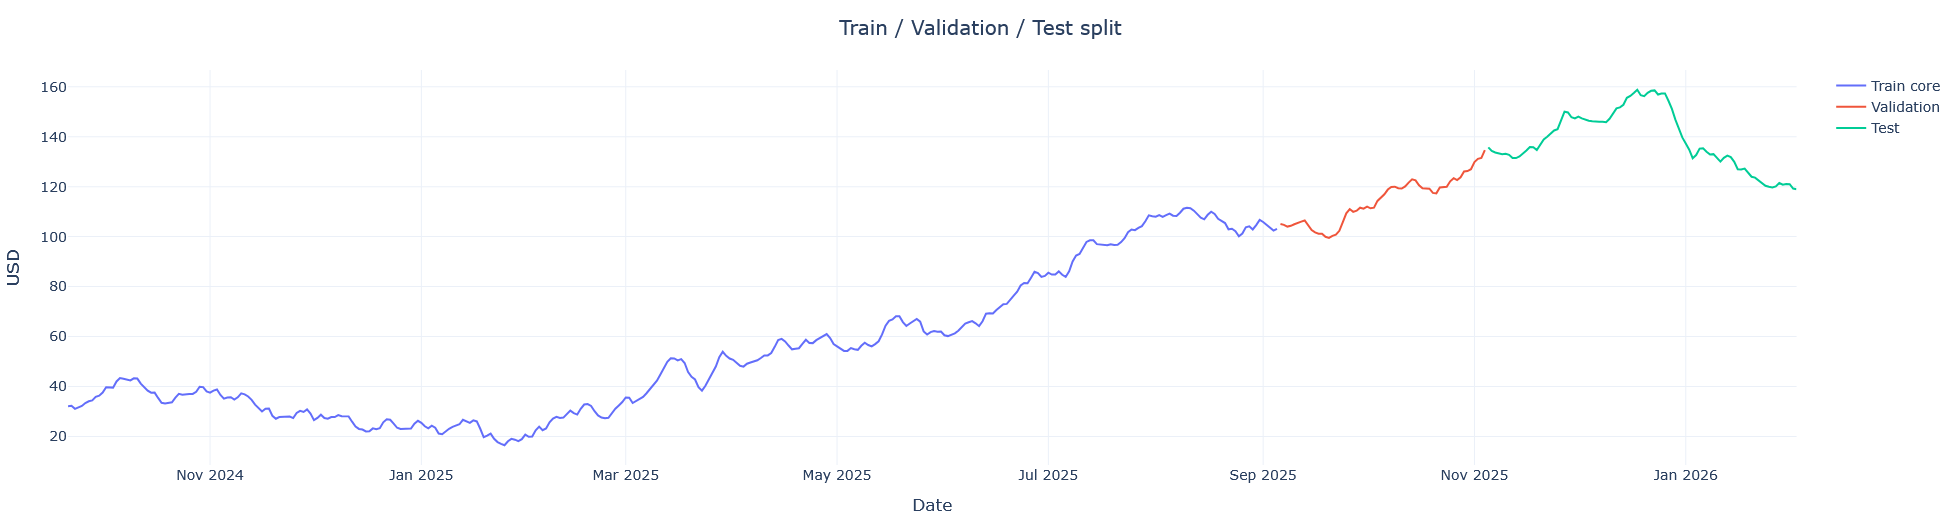

## **Loading the pretrained Delta-LSTM package**

Initially I made the LSTM where instead of predicting price directly, it predicts the next-day delta,

$$
\Delta y_t = y_t - y_{t-1}
$$

Then I reconstructed the price by,

$$
\hat{y}_t = y_{t-1} + \widehat{\Delta y_t}
$$

After a lot of experimentation, this seemed more stable.


In [ ]:
lstm_path = Path("/content/drive/MyDrive/lstm_delta.pt")
payload_lstm = torch.load(lstm_path, map_location="cpu", weights_only=False)

LOOKBACK = int(payload_lstm["lookback"])
scaler_mean = float(np.asarray(payload_lstm["scaler_mean"]).ravel()[0])
scaler_scale = float(np.asarray(payload_lstm["scaler_scale"]).ravel()[0])
lo_clip, hi_clip = payload_lstm["clip_bounds"]

print("LSTM lookback:", LOOKBACK)
print("Scaler mean/std:", scaler_mean, scaler_scale)
print("Clip bounds:", lo_clip, hi_clip)

LSTM lookback: 30
Scaler mean/std: 0.2506112469437653 1.360156710362421
Clip bounds: -2.9292000000000034 3.4588000000000143


## **Defining the Delta-LSTM model and load weights**

The inputs are sequences of $L$ standardized deltas, a hidden state and a linear layer that maps the last hidden state which are the standardized predicted delta

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

class DeltaLSTM(nn.Module):
    """
    Loadable LSTM model used to predict the next scaled delta from a lookback window
    """
    def __init__(self, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

lstm_model = DeltaLSTM(hidden=32)
lstm_model.load_state_dict(payload_lstm["state_dict"])
lstm_model = lstm_model.to(DEVICE)
lstm_model.eval()

Device: cuda


DeltaLSTM(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

## **RMSE | scaling helpers | rolling LSTM predictor**

Made some functions beforehand for the RMSE evaluation, to build delta series and to predict the next day delta from actual history, and to generate rolling 1-step price forecasts for a date index

$$
\text{RMSE} =
\sqrt{\frac{1}{n}\sum_{t=1}^{n}(y_t - \hat{y}_t)^2}
$$

The LSTM was trained on standardized deltas,

$$
z_t = \frac{\Delta y_t - \mu}{\sigma}
$$

Then I standardized inputs and predicted $\hat{z}_t$, then inverted it,

$$
\widehat{\Delta y_t} = \sigma \hat{z}_t + \mu
$$

Finally clamped $\widehat{\Delta y_t}$ into the trained clip range.

In [ ]:
def rmse(y_true, y_pred):
    """
    Compute RMSE between true values and predictions
    """
    return float(np.sqrt(mean_squared_error(np.asarray(y_true, float), np.asarray(y_pred, float))))

def inv_scale_delta(ds):
    """
    Invert standardization to convert a scaled delta back to the original delta units
    """
    return ds * scaler_scale + scaler_mean

def build_delta_series(series: pd.Series):
    """
    Return the 1-day difference series (deltas) from a level time series
    """
    return series.diff().dropna()

def lstm_predict_delta_from_history(full_y: pd.Series, target_date: pd.Timestamp):
    """
    Predict the next-day delta for target_date using only history up to target_date-1
    """
    hist = full_y.loc[:target_date - pd.Timedelta(days=1)]
    dy = build_delta_series(hist)
    window = dy.values[-LOOKBACK:].astype(np.float32)
    window_s = ((window - scaler_mean) / scaler_scale).astype(np.float32)

    x = torch.from_numpy(window_s.reshape(1, LOOKBACK, 1)).to(DEVICE)
    with torch.no_grad():
        d_s = float(lstm_model(x).cpu().numpy().item())

    d = float(inv_scale_delta(d_s))
    d = float(np.clip(d, lo_clip, hi_clip))
    return d

def lstm_rolling_1step_prices(full_y: pd.Series, eval_dates: pd.DatetimeIndex):
    """
    Generate rolling 1-step price forecasts by predicting deltas and adding them to the previous day’s price
    """
    preds = []
    for t in eval_dates:
        d_hat = lstm_predict_delta_from_history(full_y, t)
        prev_price = float(full_y.loc[t - pd.Timedelta(days=1)])
        preds.append(prev_price + d_hat)
    return np.array(preds, float)

## **ARIMA -  picking an order by AIC on log returns, then rolling 1-step forecasts**

I converted the prices to log returns, then searched $(p,q)$ for ARIMA$(p,0,q)$ using AIC. Finally, fitted the chosen ARIMA on returns and roll forwarded 1-step at a time.  
$$
r_t = \log(y_t) - \log(y_{t-1})
$$

The prices are usually nonstationary where returns are more ARIMA-friendly. ARIMA predicts $\hat{r}_t$, so,

$$
\hat{y}_t = y_{t-1}\exp(\hat{r}_t)
$$

In [ ]:
def arima_order_search_on_returns(y_series: pd.Series, p_max=6, q_max=6):
    """
    Grid-search ARIMA(p,0,q) on log returns and return the order with the lowest AIC
    """
    lp = np.log(y_series)
    r = lp.diff().dropna()

    best_aic = np.inf
    best_order = None
    best_res = None

    for p in range(p_max + 1):
        for q in range(q_max + 1):
            try:
                res = ARIMA(
                    r,
                    order=(p, 0, q),
                    trend="c",
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit()
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_order = (p, 0, q)
                    best_res = res
            except Exception:
                continue

    return best_order, best_aic, best_res

def arima_rolling_1step_prices(full_y: pd.Series, train_end_date: pd.Timestamp, eval_dates: pd.DatetimeIndex, order):
    """
    Fit ARIMA on log returns up to train_end_date, then roll 1-step forecasts and map returns back to price
    """
    lp = np.log(full_y)
    r = lp.diff().dropna()

    r_train = r.loc[:train_end_date].copy()
    if r_train.name is None:
        r_train.name = "r"

    res_roll = ARIMA(
        r_train,
        order=order,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit()

    preds = []

    for t in eval_dates:
        fc = res_roll.get_forecast(steps=1)
        r_hat = float(fc.predicted_mean.iloc[0])

        prev_price = float(full_y.loc[t - pd.Timedelta(days=1)])
        preds.append(prev_price * np.exp(r_hat))

        obs_r = float(r.loc[t])
        obs_series = pd.Series([obs_r], index=[t], name=r_train.name)

        try:
            if hasattr(res_roll, "append"):
                res_roll = res_roll.append(obs_series, refit=False)
            elif hasattr(res_roll, "extend"):
                res_roll = res_roll.extend(obs_series)
            else:
                raise AttributeError("No append/extend")
        except Exception:
            sub = r.loc[:t].copy()
            sub.name = r_train.name
            res_roll = ARIMA(
                sub,
                order=order,
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit()

    return np.array(preds, float)

## **Choosing the best ARIMA order on train core**

In [ ]:
best_arima_order, best_arima_aic, _ = arima_order_search_on_returns(y_train_core, p_max=6, q_max=6)
print("Best ARIMA order on train core:", best_arima_order, "| AIC:", best_arima_aic)

Best ARIMA order on train core: (2, 0, 1) | AIC: -1516.6260739358145


## **Comparing the base experts (ARIMA vs Delta-LSTM)**

In [ ]:
arima_val_pred = arima_rolling_1step_prices(
    full_y=y.loc[:y_val.index.max()],
    train_end_date=y_train_core.index.max(),
    eval_dates=y_val.index,
    order=best_arima_order
)

lstm_val_pred = lstm_rolling_1step_prices(
    full_y=y.loc[:y_val.index.max()],
    eval_dates=y_val.index
)

y_val_true = y_val.values.astype(float)
rmse_val_arima = rmse(y_val_true, arima_val_pred)
rmse_val_lstm = rmse(y_val_true, lstm_val_pred)
print("Validation RMSE - ARIMA:", rmse_val_arima)
print("Validation RMSE - LSTM :", rmse_val_lstm)

Validation RMSE - ARIMA: 0.9620058773003469
Validation RMSE - LSTM : 0.9738689755797787


## **Kenshi ideation core**

Instead of choosing ARIMA or LSTM once, Kenshi will update weights daily using the recent performance. It maintains a memory of recent squared errors for each expert:

$$
s_t^{(A)} = \lambda s_{t-1}^{(A)} + (1-\lambda)\left(e_{t-1}^{(A)}\right)^2
$$

$$
s_t^{(L)} = \lambda s_{t-1}^{(L)} + (1-\lambda)\left(e_{t-1}^{(L)}\right)^2
$$

Then it converts those badness scores into weights via softmax,

$$
w_t^{(L)} =
\frac{e^{-\gamma s_t^{(L)}}}
{e^{-\gamma s_t^{(L)}} + e^{-\gamma s_t^{(A)}}}
$$

$$
w_t^{(A)} = 1 - w_t^{(L)}
$$

So lower recent error means, higher the weight. Kenshi also keeps a slow bias term based on the hybrid residual, and clips it by local volatility.

$$
b_t = \rho b_{t-1} + (1-\rho)e_{t-1}^{(H)}
$$

I made a softmax helper fuction for the two numbers, then a function where kenshi predicts by blending the ARIMA and LSTM predictions online and it returns whole hybrid forecast, the weights and the bias history

In [ ]:
def _softmax_pair(sa, sb):
    """
    Stable 2-way softmax that turns two scores into weights that sum to 1
    """
    m = max(sa, sb)
    ea = np.exp(sa - m)
    eb = np.exp(sb - m)
    z = ea + eb
    return ea / z, eb / z

def kenshi_predict(y_true, pred_arima, pred_lstm, lam=0.90, gamma=6.0, rho=0.80, disagree_penalty=0.10, vol_window=7,clip_bias=3.0):
    """
    Blend ARIMA and Delta-LSTM forecasts with online error-based weights and a clipped bias correction
    """
    y_true = np.asarray(y_true, float)
    pred_arima = np.asarray(pred_arima, float)
    pred_lstm = np.asarray(pred_lstm, float)

    n = len(y_true)
    out = np.zeros(n, float)
    s_a = 1.0
    s_l = 1.0
    bias = 0.0
    e_a_prev = 0.0
    e_l_prev = 0.0
    e_h_prev = 0.0
    wL = np.zeros(n, float)
    wA = np.zeros(n, float)
    b_hist = np.zeros(n, float)

    dy = np.diff(y_true, prepend=y_true[0])

    for t in range(n):
        if t > 0:
            s_a = lam * s_a + (1 - lam) * (e_a_prev ** 2)
            s_l = lam * s_l + (1 - lam) * (e_l_prev ** 2)
            bias = rho * bias + (1 - rho) * e_h_prev

        lo = max(0, t - vol_window)
        vol_t = np.std(dy[lo:t+1]) if t > 0 else np.std(dy[:min(n, vol_window+1)])
        vol_t = float(max(vol_t, 1e-6))
        score_l = -gamma * s_l
        score_a = -gamma * s_a
        w_l, w_a = _softmax_pair(score_l, score_a)
        d = pred_lstm[t] - pred_arima[t]
        if abs(d) > 2.0 * vol_t:
            w_l = max(0.0, w_l - disagree_penalty)
            w_a = 1.0 - w_l

        bias_used = float(np.clip(bias, -clip_bias * vol_t, clip_bias * vol_t))

        y_hat = w_l * pred_lstm[t] + w_a * pred_arima[t] + bias_used
        out[t] = max(0.0, y_hat)
        e_a_prev = y_true[t] - pred_arima[t]
        e_l_prev = y_true[t] - pred_lstm[t]
        e_h_prev = y_true[t] - out[t]
        wL[t] = w_l
        wA[t] = w_a
        b_hist[t] = bias_used

    return out, wL, wA, b_hist

## **Tuning Kenshi hyperparameters on validation split**

Here, I am brute forcing grid search over, error memory decay $(λ)$, softmax sharpness $(γ)$, bias smoothing $(ρ)$ and diagree_penalty argument that acts like a safety clamp when the experts diverge unusually

In [ ]:
grid_lam = [0.80, 0.90, 0.95]
grid_gamma = [2.0, 4.0, 6.0, 8.0]
grid_rho = [0.50, 0.80, 0.90]
grid_pen = [0.00, 0.05, 0.10, 0.15]

best_cfg = None
best_val_rmse = np.inf
best_val_pred = None
best_val_diag = None

for lam in grid_lam:
    for gamma in grid_gamma:
        for rho in grid_rho:
            for pen in grid_pen:
                pred_h, wL_val, wA_val, b_val = kenshi_predict(
                    y_true=y_val_true,
                    pred_arima=arima_val_pred,
                    pred_lstm=lstm_val_pred,
                    lam=lam,
                    gamma=gamma,
                    rho=rho,
                    disagree_penalty=pen,
                )
                score = rmse(y_val_true, pred_h)
                if score < best_val_rmse:
                    best_val_rmse = score
                    best_cfg = dict(lam=lam, gamma=gamma, rho=rho, disagree_penalty=pen)
                    best_val_pred = pred_h
                    best_val_diag = (wL_val, wA_val, b_val)

print("Validation RMSE - ARIMA:", rmse_val_arima)
print("Validation RMSE - LSTM :", rmse_val_lstm)
print("Validation RMSE - Kenshi:", best_val_rmse)
print("Best Kenshi config:", best_cfg)

Validation RMSE - ARIMA: 0.9620058773003469
Validation RMSE - LSTM : 0.9738689755797787
Validation RMSE - Kenshi: 0.960990585940853
Best Kenshi config: {'lam': 0.8, 'gamma': 8.0, 'rho': 0.9, 'disagree_penalty': 0.0}


## **Rolling 1-step performance on test split evaluation**

First building the ARIMA rolling predictions through the test window, then building LSTM rolling predictions through the test window and finally running the Kenshi hybrid model.

In [ ]:
selected_mode = "hybrid"  # defining it to make it explicit
arima_test_pred = arima_rolling_1step_prices(
    full_y=y,
    train_end_date=y_train_full.index.max(),
    eval_dates=y_test.index,
    order=best_arima_order
)

lstm_test_pred = lstm_rolling_1step_prices(
    full_y=y,
    eval_dates=y_test.index
)

y_test_true = y_test.values.astype(float)

if selected_mode == "hybrid":
    kenshi_test_pred, wL_test, wA_test, b_test = kenshi_predict(
        y_true=y_test_true,
        pred_arima=arima_test_pred,
        pred_lstm=lstm_test_pred,
        **best_cfg
    )
elif selected_mode == "lstm":
    kenshi_test_pred = np.asarray(lstm_test_pred, float)
    wL_test = np.ones_like(kenshi_test_pred)
    wA_test = np.zeros_like(kenshi_test_pred)
    b_test = np.zeros_like(kenshi_test_pred)
else:
    kenshi_test_pred = np.asarray(arima_test_pred, float)
    wL_test = np.zeros_like(kenshi_test_pred)
    wA_test = np.ones_like(kenshi_test_pred)
    b_test = np.zeros_like(kenshi_test_pred)

rmse_test_arima = rmse(y_test_true, arima_test_pred)
rmse_test_lstm = rmse(y_test_true, lstm_test_pred)
rmse_test_kenshi = rmse(y_test_true, kenshi_test_pred)

print("Test RMSE - ARIMA :", rmse_test_arima)
print("Test RMSE - LSTM  :", rmse_test_lstm)
print("Test RMSE - Kenshi:", rmse_test_kenshi)

Test RMSE - ARIMA : 1.2076765439302346
Test RMSE - LSTM  : 1.1318238658286344
Test RMSE - Kenshi: 1.0934499434031064


## **Plotting the rolling 1-step forecasts**

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=y_train_full.index, y=y_train_full.values, name="Train", line=dict(width=2)))
fig.add_trace(go.Scatter(x=y_test.index, y=y_test.values, name="Test", line=dict(width=2)))
fig.add_trace(go.Scatter(x=y_test.index, y=arima_test_pred, name="ARIMA 1-step", line=dict(width=2)))
fig.add_trace(go.Scatter(x=y_test.index, y=lstm_test_pred, name="Delta-LSTM 1-step", line=dict(width=2)))
fig.add_trace(go.Scatter(x=y_test.index, y=kenshi_test_pred, name=f"Kenshi ({selected_mode})", line=dict(width=3)))

fig.update_layout(
    template="plotly_white",
    title=dict(text="Kenshi hybrid rolling 1-step test forecast", x=0.5),
    xaxis_title="Date",
    yaxis_title="USD",
    font=dict(size=14),
    margin=dict(l=60, r=30, t=70, b=60),
)
fig.show()

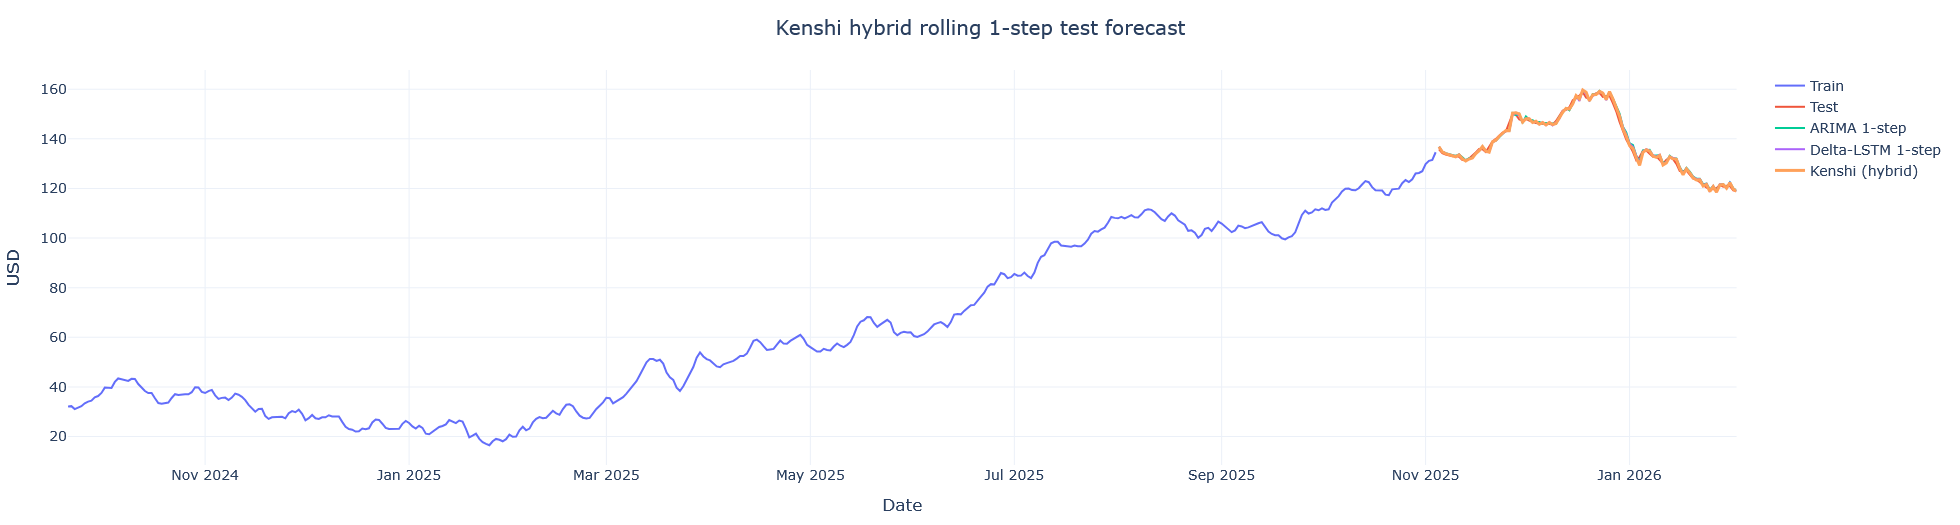

## **Plotting the Kenshi's expert dynamic weights**

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=y_test.index, y=wL_test, name="LSTM weight", line=dict(width=2)))
fig.add_trace(go.Scatter(x=y_test.index, y=wA_test, name="ARIMA weight", line=dict(width=2)))

fig.update_layout(
    template="plotly_white",
    title=dict(text=f"Kenshi dynamic expert weights on test window (mode={selected_mode})", x=0.5),
    xaxis_title="Date",
    yaxis_title="Weight",
    yaxis=dict(range=[0, 1]),
    font=dict(size=14),
    margin=dict(l=60, r=30, t=70, b=60),
)
fig.show()

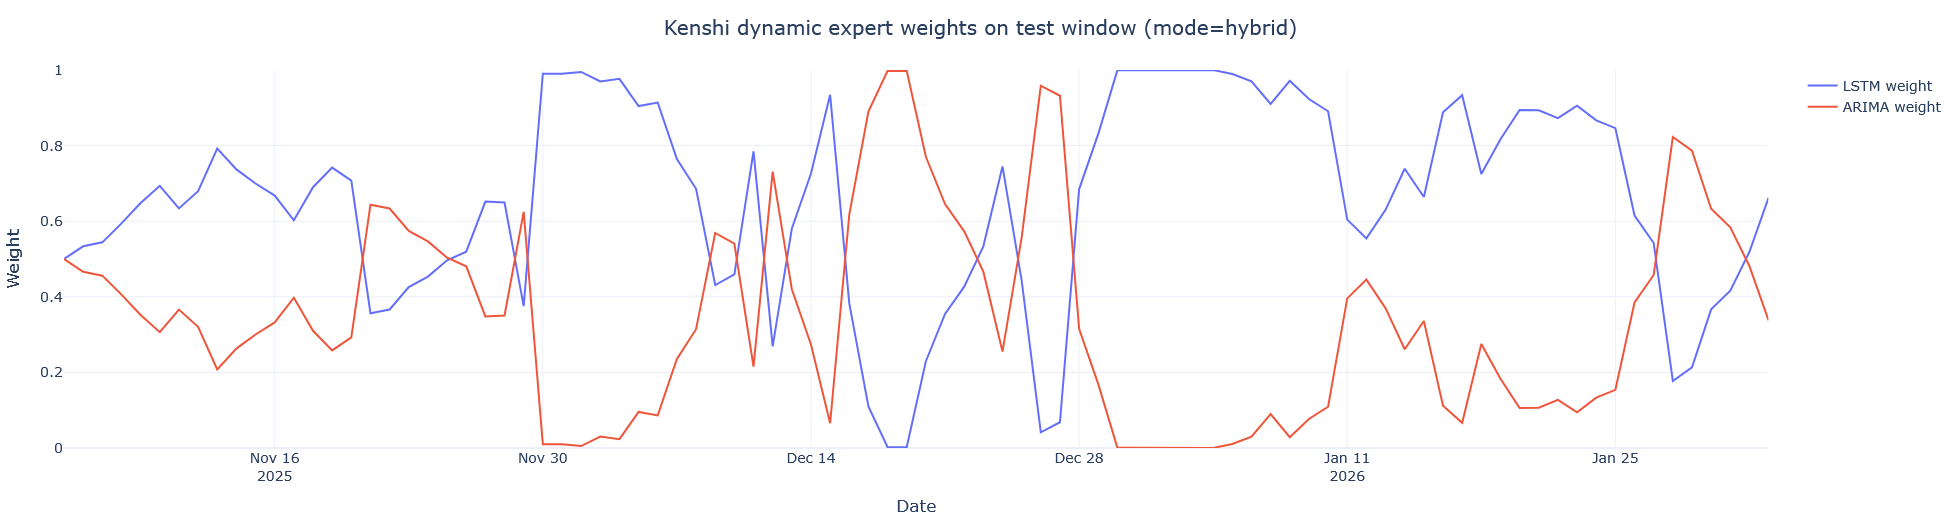

The two curves LSTM weight $w_t^{(L)}$, ARIMA weight $w_t^{(A)}$ always sum to $\sim 1$. When $w_t^{(L)}$ rises, Kenshi trusts the LSTM more, when $w_t^{(A)}$ rises, Kenshi trusts ARIMA more and the sharp transitions usually means that one model started missing and the other started tracking better.

## **24-month forecast on Kenshi's hybrid model**

First, I am fitting ARIMA on the full return series. Then, simulating $S$ future return paths for $H$ days. Finally converted the returns into price paths. The simulated returns $\tilde{r}_{t+1}, \ldots, \tilde{r}_{t+H}$ becomes log price,

$$
\log \tilde{y}_{t+h}
=
\log y_t
+
\sum_{j=1}^{h} \tilde{r}_{t+j}
$$

$$
\tilde{y}_{t+h} = \exp\!\left(\log \tilde{y}_{t+h}\right)
$$

In [ ]:
lp = np.log(y)
r = lp.diff().dropna()

res_arima_full = ARIMA(
    r,
    order=best_arima_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

fc_start = y.index.max() + pd.Timedelta(days=1)
fc_end = y.index.max() + pd.DateOffset(months=24)
fc_dates = pd.date_range(fc_start, fc_end, freq="D")
H = len(fc_dates)

S = 400

sim_r = res_arima_full.simulate(nsimulations=H, repetitions=S, anchor="end")
sim_r = np.asarray(sim_r)

if sim_r.shape[0] == H:
    sim_r = sim_r.T

last_lp = float(lp.iloc[-1])

sim_lp = last_lp + np.cumsum(sim_r, axis=1)
arima_paths = np.exp(sim_lp)  # (S, H)

## **Building the LSTM residual bootstrap noise**

I will create 1-step LSTM predictions on training window, then convert those into deltas and computing historical delta residuals, $e_t = (\Delta y_t) - (\widehat{\Delta y_t})$, then store them for bootstrap sampling.

In [ ]:
valid_start_pos = LOOKBACK + 1
train_lstm_resid_dates = y_train_full.index[valid_start_pos:]
lstm_train_price_pred = lstm_rolling_1step_prices(full_y=y.loc[:y_train_full.index.max()], eval_dates=train_lstm_resid_dates)
true_train_price = y.loc[train_lstm_resid_dates].values.astype(float)
prev_train_price = y.shift(1).loc[train_lstm_resid_dates].values.astype(float)
true_train_delta = true_train_price - prev_train_price
pred_train_delta = lstm_train_price_pred - prev_train_price
resid_delta = true_train_delta - pred_train_delta
resid_delta = resid_delta[np.isfinite(resid_delta)]

print("LSTM bootstrap residual count:", len(resid_delta))
print("First valid residual date:", train_lstm_resid_dates[0])

LSTM bootstrap residual count: 379
First valid residual date: 2024-10-22 00:00:00


## **Rolling out LSTM Monte Carlo paths**

Starting from the last LOOKBACK deltas, the function will predict the delta via LSTM, adds bootstrap noise, clips the delta, updates the price and shifts the delta window forward.

In [ ]:
dy_full = y.diff().dropna().values.astype(np.float32)
window0 = dy_full[-LOOKBACK:].copy()

def lstm_rollout_path(window_init, H, noise=None, seed_price=None):
    """
    Roll the Delta-LSTM forward for H steps to produce a price path
    """
    w = window_init.copy()
    price = float(y.iloc[-1] if seed_price is None else seed_price)
    out = np.zeros(H, float)

    for t in range(H):
        w_s = ((w - scaler_mean) / scaler_scale).astype(np.float32)
        x = torch.from_numpy(w_s.reshape(1, LOOKBACK, 1)).to(DEVICE)

        with torch.no_grad():
            d_s = float(lstm_model(x).cpu().numpy().item())

        d = float(inv_scale_delta(d_s))
        if noise is not None:
            d += float(noise[t])

        d = float(np.clip(d, lo_clip, hi_clip))

        price = max(0.0, price + d)
        out[t] = price

        w = np.roll(w, -1)
        w[-1] = d

    return out

rng = np.random.default_rng(42)

lstm_paths = np.zeros((S, H), float)
for s in range(S):
    noise = rng.choice(resid_delta, size=H, replace=True)
    lstm_paths[s] = lstm_rollout_path(window0, H, noise=noise, seed_price=float(y.iloc[-1]))

## **Building Kenshi hybrid model**

First step would be to converting the ARIMA and LSTM price paths into delta paths. Then, Kenshi blend the deltas with horizon dependant weights. It stabilizes the long horizon with weight mean reversion by 0.5, then doing drift neutralization after 120 days and by clipping the deltas 1% to 99% historical quantiles. Finally Kenshi will converts them back to price paths and computes quantiles (median and 95% CI). In theory it goes like this,

First for given path prices $\tilde{y}_{t+h}$, Kenshi computes,

$$
\Delta \tilde{y}_{t+h} = \tilde{y}_{t+h} - \tilde{y}_{t+h-1}
$$


For the weight mean reversion, Kenshi starts from last observed test weight $w_{L,0}$ and decay to $0.5$,

$$
w_L(h) =
w_{\text{floor}} +
\left(w_{L,0} - w_{\text{floor}}\right)
\exp\!\left(-\frac{h-1}{\tau_w}\right)
$$

This prevents one expert from owning the entire two-year horizon. After $h_0 = 120$, Kenshi gradually shrinks delta forecasts toward a conservative drift target $\mu_{\text{target}}$,

$$
\Delta \tilde{y}^{(H)}
=
(1-\eta_h)\Delta \tilde{y}^{(\text{raw})}
+
\eta_h \mu_{\text{target}}
$$


Finally, Kenshi clips them to empirical $[q_{0.01}, q_{0.99}]$ of historical deltas.

In [ ]:
last_price = float(y.iloc[-1])
arima_delta_paths = np.diff(
    np.concatenate([np.full((arima_paths.shape[0], 1), last_price), arima_paths], axis=1),
    axis=1
)
lstm_delta_paths = np.diff(
    np.concatenate([np.full((lstm_paths.shape[0], 1), last_price), lstm_paths], axis=1),
    axis=1
)

all_delta = y.diff().dropna().values.astype(float)
recent_delta = y.diff().dropna().iloc[-90:].values.astype(float)

recent_vol = float(np.std(recent_delta))
full_med = float(np.median(all_delta))
recent_med = float(np.median(recent_delta))
target_mu_raw = 0.5 * full_med
target_mu = float(np.clip(target_mu_raw, -0.15 * recent_vol, 0.15 * recent_vol))
d_lo, d_hi = np.quantile(all_delta, [0.01, 0.99])

print("Recent median delta (for reference only):", recent_med)
print("Full-sample median delta:", full_med)
print("Recent vol:", recent_vol)
print("Using neutralized target drift:", target_mu)
print("Delta clip range:", float(d_lo), float(d_hi))

wL0 = float(wL_test[-1]) if len(wL_test) else 0.5
wL_floor = 0.50
tau_w = 120.0

h = np.arange(1, H + 1, dtype=float)
wL_h = wL_floor + (wL0 - wL_floor) * np.exp(-(h - 1) / tau_w)
wA_h = 1.0 - wL_h
hyb_delta_raw = wL_h[None, :] * lstm_delta_paths + wA_h[None, :] * arima_delta_paths

h0 = 120.0
tau_mu = 180.0
eta_max = 0.35
eta_h = np.where(h <= h0, 0.0, 1.0 - np.exp(-(h - h0) / tau_mu))
eta_h = np.minimum(eta_h, eta_max)
hyb_delta_adj = (1.0 - eta_h[None, :]) * hyb_delta_raw + eta_h[None, :] * target_mu
hyb_delta_adj = np.clip(hyb_delta_adj, d_lo, d_hi)
kenshi_paths = last_price + np.cumsum(hyb_delta_adj, axis=1)
kenshi_paths = np.maximum(kenshi_paths, 0.0)

p50 = np.quantile(kenshi_paths, 0.50, axis=0)
p025 = np.quantile(kenshi_paths, 0.025, axis=0)
p975 = np.quantile(kenshi_paths, 0.975, axis=0)

print("Forecast LSTM weight start:", float(wL_h[0]))
print("Forecast LSTM weight end  :", float(wL_h[-1]))
print("24-month horizon days:", H)

Recent median delta (for reference only): -0.12000000000000455
Full-sample median delta: 0.1599999999999966
Recent vol: 1.5638051724188502
Using neutralized target drift: 0.0799999999999983
Delta clip range: -3.3804000000000234 3.490800000000008
Forecast LSTM weight start: 0.6622933067619213
Forecast LSTM weight end  : 0.5003732171839287
24-month horizon days: 730


## **Plotting the 24-month Kenshi forecast with 95% interval**

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=y.index, y=y.values, name="Historical", line=dict(width=2)))
fig.add_trace(go.Scatter(x=fc_dates, y=p975, line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(x=fc_dates, y=p025, fill="tonexty", name="95% CI",line=dict(width=0)))
fig.add_trace(go.Scatter(x=fc_dates, y=p50, name="Kenshi forecast (median)", line=dict(width=2)))
start_view = y.index.max() - pd.DateOffset(months=18)
fig.update_xaxes(range=[start_view, fc_dates[-1]])
upper_cap = float(np.quantile(p975, 0.98))
upper_cap = max(upper_cap, float(y.max()) * 1.1)
fig.update_yaxes(range=[0, upper_cap * 1.05])
fig.update_layout(
    template="plotly_white",
    title=dict(text="Kenshi hybrid: 24-month forecast", x=0.5),
    xaxis_title="Date",
    yaxis_title="USD",
    font=dict(size=14),
    margin=dict(l=60, r=30, t=70, b=60),
)
fig.show()

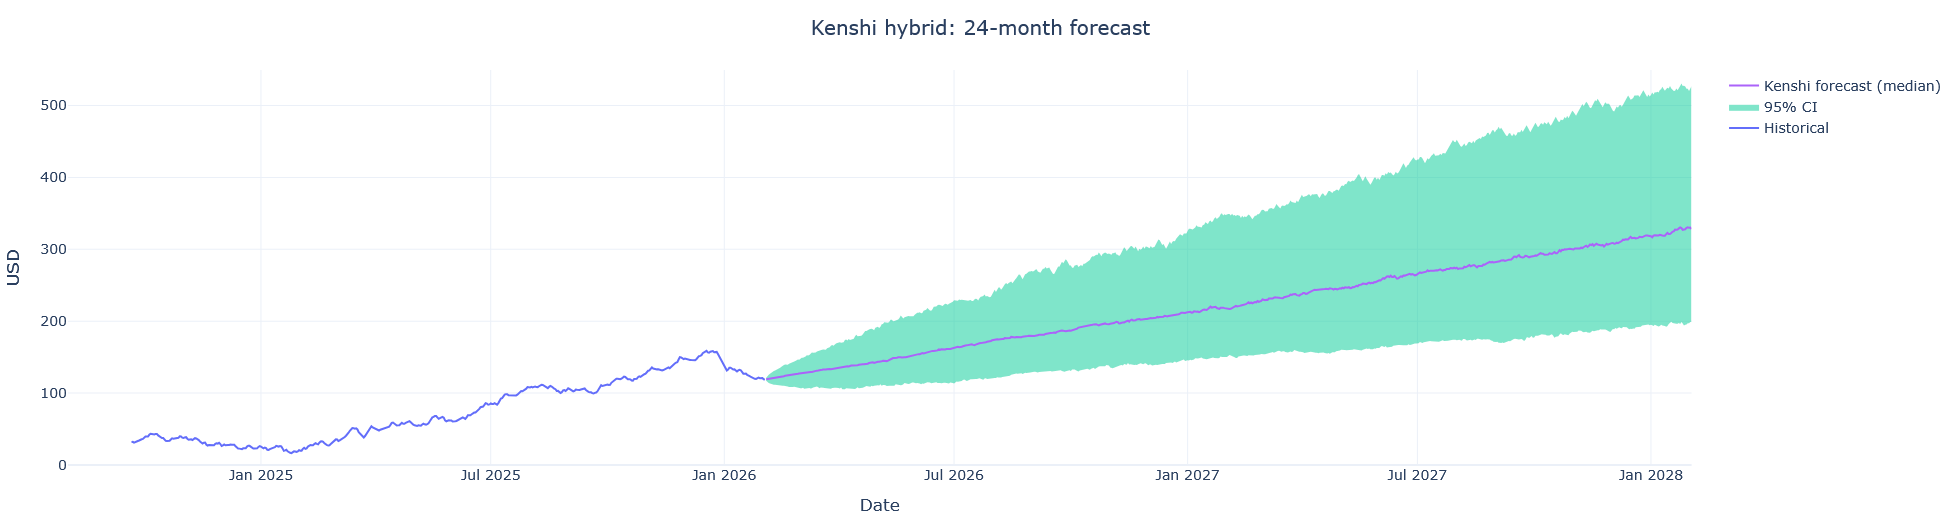

The 24-month forecast shows a steady upward central path from the latest observed price level. The prediction interval widens quickly with horizon, indicating substantially higher uncertainty the farther out the forecast goes.

## **Saving Outputs**

In [ ]:
out_dir = Path("../models")
out_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    "date": fc_dates,
    "p025": p025,
    "p50": p50,
    "p975": p975
}).to_csv(out_dir / "kenshi_hybrid_24m_forecast.csv", index=False)

wL_last = float(wL_test[-1]) if len(wL_test) else 0.5
wA_last = float(wA_test[-1]) if len(wA_test) else 0.5

with open(out_dir / "kenshi_hybrid_metrics.pkl", "wb") as f:
    pickle.dump(
        {
            "selected_mode": selected_mode,
            "best_arima_order": best_arima_order,
            "best_kenshi_config": best_cfg,
            "rmse_val_arima": rmse_val_arima,
            "rmse_val_lstm": rmse_val_lstm,
            "rmse_val_kenshi": best_val_rmse,
            "rmse_test_arima": rmse_test_arima,
            "rmse_test_lstm": rmse_test_lstm,
            "rmse_test_kenshi": rmse_test_kenshi,
            "final_weight_lstm": wL_last,
            "final_weight_arima": wA_last,
            "model": "Kenshi hybrid (ARIMA + Delta-LSTM dynamic mixture)"
        },
        f
    )

print("Saved:", out_dir / "kenshi_hybrid_24m_forecast.csv")
print("Saved:", out_dir / "kenshi_hybrid_metrics.pkl")

Saved: ../models/kenshi_hybrid_24m_forecast.csv
Saved: ../models/kenshi_hybrid_metrics.pkl
